# Visualize QA-inference results

Quick plots for tables produced by `scripts/run_qa_inference.py`
(`data/qa_inference_small.parquet` and similar): the two top-token rates
(`top_is_correct`, `top_is_candidate`) and the `logprob_diff` distribution, each
with 95% confidence intervals — overall and split by a grouping column.

Launch against the project venv so the kernel matches: `uv run jupyter lab`.

In [1]:
# Load .env first (thread caps etc.) per repo convention, before heavy imports.
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

## Load a QA-inference dataset

Point `DATA` at any table produced by `scripts/run_qa_inference.py` — e.g.
`data/qa_inference_small.parquet`, generated with:

```
uv run scripts/run_qa_inference.py --limit 96 --batch-size 48 --out data/qa_inference_small.parquet
```

In [2]:
DATA = next(p for p in [Path("data/qa_inference_small.parquet"),
                        Path("../data/qa_inference_small.parquet")] if p.exists())
df = pd.read_parquet(DATA)
print(f"{DATA}  —  {len(df)} rows")

# Headline numbers (mirror what run_qa_inference.py prints at the end).
print(f"  accuracy (winner==correct):  {df.model_correct.mean():.1%}")
print(f"  top token is a candidate:    {df.top_is_candidate.mean():.1%}")
print(f"  top token is correct:        {df.top_is_correct.mean():.1%}")
print(f"  mean logprob_diff (cor-inc): {df.logprob_diff.mean():+.3f}")
print(f"  forced-close rate:           {df.forced_close.mean():.1%}")
df.head(3)

../data/qa_inference_small.parquet  —  96 rows
  accuracy (winner==correct):  83.3%
  top token is a candidate:    100.0%
  top token is correct:        83.3%
  mean logprob_diff (cor-inc): +5.820
  forced-close rate:           33.3%


,qid,prop_id,comparison,expected_answer,value_diff,topic,correct_name,incorrect_name,correct_token_id,incorrect_token_id,...,winner,model_correct,top_is_correct,top_is_candidate,think_text,think_token_ids,n_think_tokens,forced_close,seed,batch_index
0,e6fa0245df3eb7a1e09702700161932e40c71c9cded379...,wm-us-zip-lat,gt,NO,6.43592,about US zip codes,"85345, AZ","34990, FL",25724,18634,...,correct,True,True,True,"First, I need to determine the latitude of bot...","[5451, 11, 358, 1205, 311, 8417, 279, 21518, 3...",126,False,47,0
1,de4284e19b43548e33d09514ca3fc67939d9d8e7d99191...,wm-book-release,lt,NO,5334.00000,about books,Neal Stephenson's Quicksilver,Chuck Palahniuk's Adjustment Day,94682,94626,...,incorrect,False,False,True,"Okay, so I need to figure out which book came ...","[33413, 11, 779, 358, 1205, 311, 7216, 704, 90...",492,False,47,0
2,0e23b536be990cf69e8da9a863a0866ff403766d4d24f4...,wm-us-zip-long,lt,YES,12.91341,about US zip codes,"76001, TX","45449, OH",19104,20555,...,correct,True,True,True,"Okay, so I need to figure out which of these t...","[33413, 11, 779, 358, 1205, 311, 7216, 704, 90...",974,False,47,0


### Confidence-interval helpers

- **Proportions** (`top_is_correct`, `top_is_candidate`): **Wilson** 95% interval —
  well-behaved near 0/1, unlike the normal approximation.
- **`logprob_diff`**: mean +/- 1.96*SEM (normal approx; fine at this sample size).

In [3]:
Z = 1.96  # 95%

def wilson(k, n, z=Z):
    "Wilson score interval for a proportion: returns (p_hat, lo, hi)."
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, center - half, center + half

def prop_ci(mask, z=Z):
    "Wilson CI for a boolean Series -> (p_hat, lo, hi)."
    mask = pd.Series(mask).dropna()
    return wilson(int(mask.sum()), int(len(mask)), z)

def mean_ci(x, z=Z):
    "Mean +/- z*SEM for a numeric Series -> (mean, lo, hi)."
    x = pd.Series(x).dropna()
    m = x.mean()
    sem = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return m, m - z * sem, m + z * sem

## Headline metrics

Left: the two boolean top-token rates with Wilson 95% CIs. Right: the
`logprob_diff` distribution with its mean and 95% CI (positive => the model favors
the **correct** entity's first token over the incorrect one's).

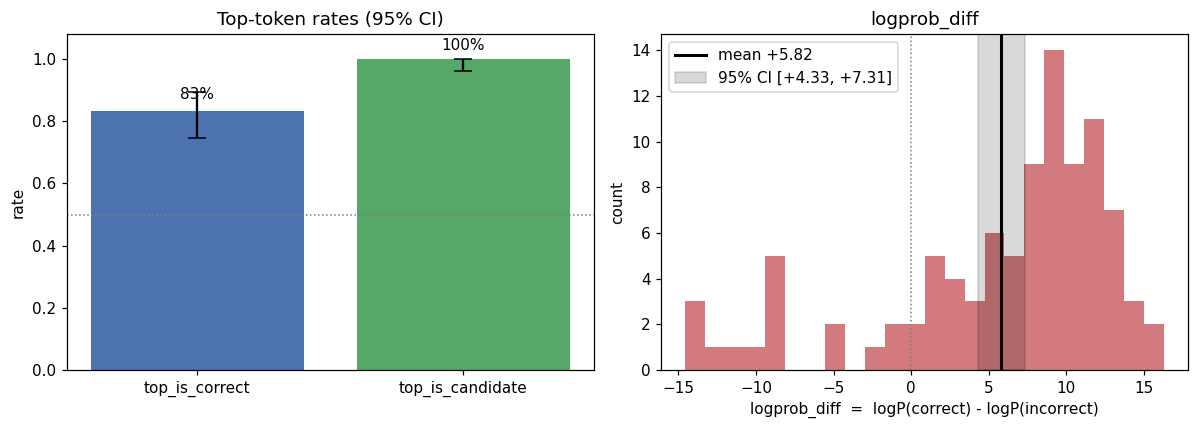

In [4]:
fig, (ax_rate, ax_lpd) = plt.subplots(1, 2, figsize=(11, 4))

# --- boolean rates with Wilson 95% CI ---
bool_cols = ["top_is_correct", "top_is_candidate"]
pts, errs = [], [[], []]
for c in bool_cols:
    p, lo, hi = prop_ci(df[c])
    pts.append(p); errs[0].append(p - lo); errs[1].append(hi - p)
ax_rate.bar(bool_cols, pts, yerr=errs, capsize=6, color=["#4C72B0", "#55A868"])
for i, p in enumerate(pts):
    ax_rate.text(i, min(p + 0.03, 1.02), f"{p:.0%}", ha="center", va="bottom")
ax_rate.set_ylim(0, 1.08); ax_rate.set_ylabel("rate")
ax_rate.set_title("Top-token rates (95% CI)")
ax_rate.axhline(0.5, ls=":", c="grey", lw=1)

# --- logprob_diff distribution + mean & 95% CI ---
m, lo, hi = mean_ci(df.logprob_diff)
ax_lpd.hist(df.logprob_diff, bins=24, color="#C44E52", alpha=0.75)
ax_lpd.axvline(0, ls=":", c="grey", lw=1)
ax_lpd.axvline(m, c="k", lw=2, label=f"mean {m:+.2f}")
ax_lpd.axvspan(lo, hi, color="k", alpha=0.15, label=f"95% CI [{lo:+.2f}, {hi:+.2f}]")
ax_lpd.set_xlabel("logprob_diff  =  logP(correct) - logP(incorrect)")
ax_lpd.set_ylabel("count"); ax_lpd.set_title("logprob_diff"); ax_lpd.legend()

fig.tight_layout()

## Breakdown by a grouping column

The same three metrics split by any categorical column (`comparison`,
`expected_answer`, `prop_id`, `topic`, `forced_close`, ...), each with 95% CIs and
per-group counts. Sparse groups (e.g. `prop_id` on a small sample) get wide
intervals - read those with care.

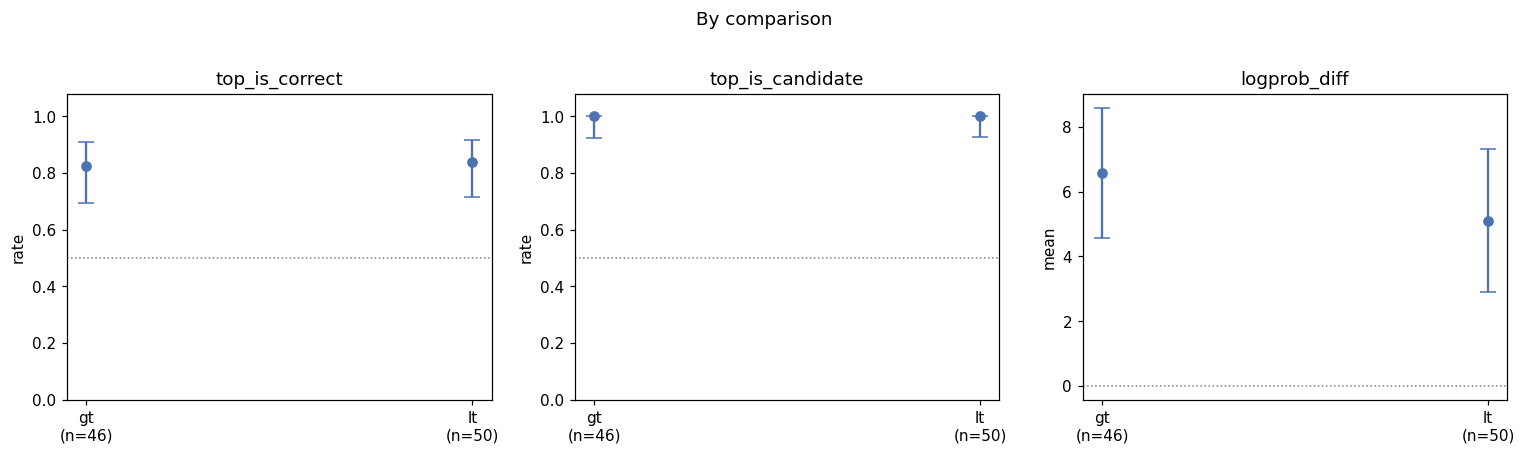

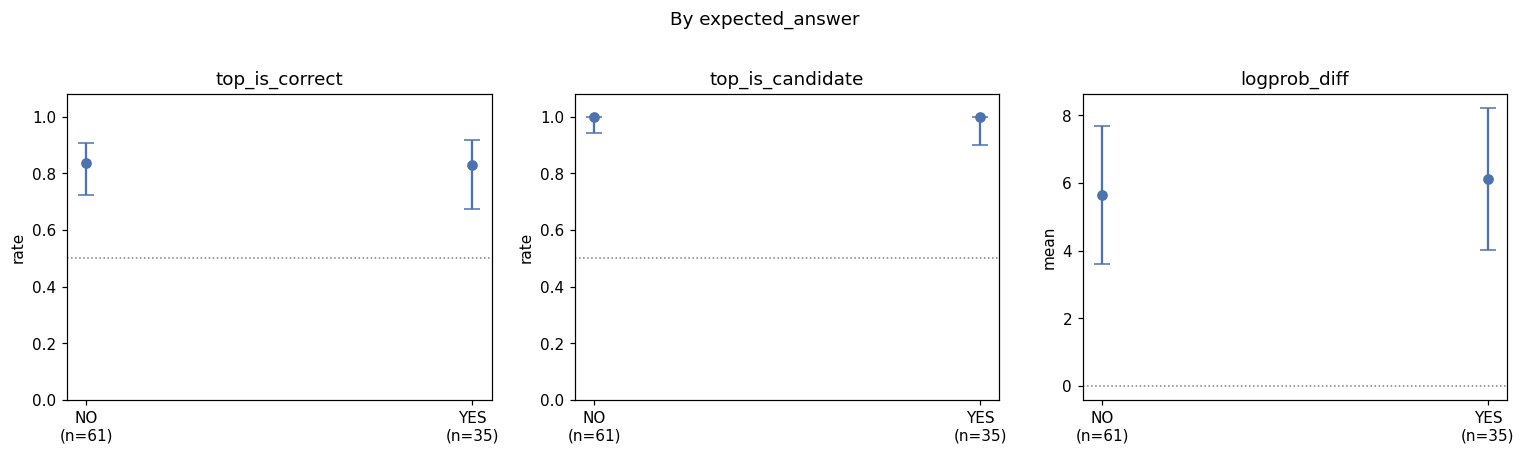

In [5]:
def plot_by_group(col, data=None):
    "Rates of the two booleans + mean logprob_diff, grouped by `col`, with 95% CIs."
    data = df if data is None else data
    groups = sorted(data[col].dropna().unique().tolist(), key=str)
    n = data.groupby(col).size()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    specs = [("top_is_correct", "rate", prop_ci),
             ("top_is_candidate", "rate", prop_ci),
             ("logprob_diff", "mean", mean_ci)]
    for ax, (metric, kind, ci) in zip(axes, specs):
        pts, lo_err, hi_err = [], [], []
        for g in groups:
            est, lo, hi = ci(data[data[col] == g][metric])
            pts.append(est); lo_err.append(est - lo); hi_err.append(hi - est)
        x = np.arange(len(groups))
        ax.errorbar(x, pts, yerr=[lo_err, hi_err], fmt="o", capsize=5, color="#4C72B0")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{g}\n(n={n[g]})" for g in groups])
        ax.set_title(metric); ax.set_ylabel(kind)
        if kind == "rate":
            ax.set_ylim(0, 1.08); ax.axhline(0.5, ls=":", c="grey", lw=1)
        else:
            ax.axhline(0, ls=":", c="grey", lw=1)
    fig.suptitle(f"By {col}", y=1.02); fig.tight_layout()

plot_by_group("comparison")
plot_by_group("expected_answer")